# Summary statistics for the dataset

This notebook plots the intial descriptive graphs. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from elasticsearch import Elasticsearch

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
import elastic_search_fncs as esf

There are two datasets loaded here - the dataset of all planning applciation IDs for 2021 onwards across the 8 relevant london councils. Plus the comments dataset - which is the free-text comments we've been able to scrape from the council websites. 

### Dataset 1 - geo boundaries 

In [2]:
london_lad = gpd.read_file('../data/Local_Authority_Districts_May_2024_London.geojson')


### Dataset 2 - applications

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

# format 'borough' column so 'City of London' not 'City Of London'
application_df['borough'] = application_df['borough'].replace({'City Of London':'City of London'})

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


### Dataset 3 - comments 

In [4]:
# Comments dataset
cs = Comments()
comment_df = cs.read_all().copy()
comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,78790,Ealing,230384FUL_16,230384FUL,2 Tring Avenue London W5 3QA W5 3QA,Objects,2023-02-27,This development is out of keeping with the ar...,2025-04-08,51.50873,-0.28956,This development is out of keeping with the ar...,E09000009,-0.596320
1,98844,Barnet,21/3676/FUL_537,21/3676/FUL,7 Park Road New Barnet EN4 9QA,Objects,2021-08-30,Dear Sirs\nI wish to register my objection to ...,2025-04-11,51.65192,-0.16772,Dear Sirs\nI wish to register my objection to ...,E09000003,-0.247984
2,76145,Lambeth,21/03147/FUL_6,21/03147/FUL,None,Objects,2022-08-02,The applicant proposes green/blue roofs and pe...,2025-04-08,NaN,NaN,The applicant proposes green/blue roofs and pe...,None,-0.231393
3,78796,Ealing,230384FUL_22,230384FUL,18 Tring Avenue ealing W5 3QA W5 3QA,Objects,2023-02-23,this sort of development is not appropriate fo...,2025-04-08,51.50873,-0.28956,this sort of development is not appropriate fo...,E09000009,-0.451211
4,78789,Ealing,230384FUL_15,230384FUL,36 Tring Avenue Londdon W5 3QB W5 3QB,Objects,2023-02-27,"The development seems excessive for the area, ...",2025-04-08,51.50707,-0.28793,"The development seems excessive for the area, ...",E09000009,-0.484850


In [5]:
# format 'council' column so 'City of London' not 'City Of London'
comment_df['council'] = comment_df['council'].replace({'City Of London':'City of London'})

print(f"The councils in the dataset are: {comment_df['council'].unique()}")

The councils in the dataset are: ['Ealing' 'Barnet' 'Lambeth' 'Westminster' 'Southwark' 'Brent' 'Newham'
 'City of London']


In [6]:
print(f"Total number of comments: {len(comment_df)}")
print(f"Total number of applications (with comments scraped): {len(comment_df.application_id.unique())}")

Total number of comments: 30393
Total number of applications (with comments scraped): 2453


In [7]:
comment_df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [8]:
# groupby council - number of comments per application
# Get number of unique applications and comments per council
unique_app_counts = comment_df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Rename for clarity
unique_app_counts.columns = ['council', 'no_applications_with_comments', 'total_comment_count']

# Compute mean number of comments per application
unique_app_counts['mean_comments_per_application'] = (
    unique_app_counts['total_comment_count'] / unique_app_counts['no_applications_with_comments']
)

# groupby council - number of applications
count_df = application_df.groupby('borough').size()
count_df = pd.DataFrame(count_df).reset_index().rename(columns={0:'no_applications'})

# merge 
unique_app_counts = pd.merge(unique_app_counts, count_df, left_on='council', right_on='borough', how='left')
unique_app_counts.drop(columns=['borough'], inplace=True)

# Sort data
unique_app_counts = unique_app_counts.sort_values(by='no_applications', ascending=True)

unique_app_counts

,council,no_applications_with_comments,total_comment_count,mean_comments_per_application,no_applications
2,City of London,14,38,2.714286,21
6,Southwark,152,2488,16.368421,308
5,Newham,158,750,4.746835,424
4,Lambeth,208,2587,12.437500,483
7,Westminster,238,1347,5.659664,493
1,Brent,395,2419,6.124051,935
3,Ealing,497,11592,23.323944,1122
0,Barnet,791,9172,11.595449,1291


### Local authority plot 

Plot a map of London with the local authorities with web-scraped data higlighted 

In [9]:
# list of councils to highlight
councils = unique_app_counts['council'].tolist()

In [10]:
# format comment_df lat and lon to london_lad crs
# assuming original are (EPSG:27700)
comment_gdf = gpd.GeoDataFrame(
    comment_df,
    geometry=gpd.points_from_xy(comment_df.lon, comment_df.lat),
    crs="EPSG:4326"
)

comment_gdf = comment_gdf.to_crs(london_lad.crs)

In [11]:
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side


In [12]:
# Bounding box
minx, miny, maxx, maxy = london_lad.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad[london_lad['LAD24NM'].isin(councils)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_73581/64958339.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted['centroid'] = highlighted.geometry.centroid


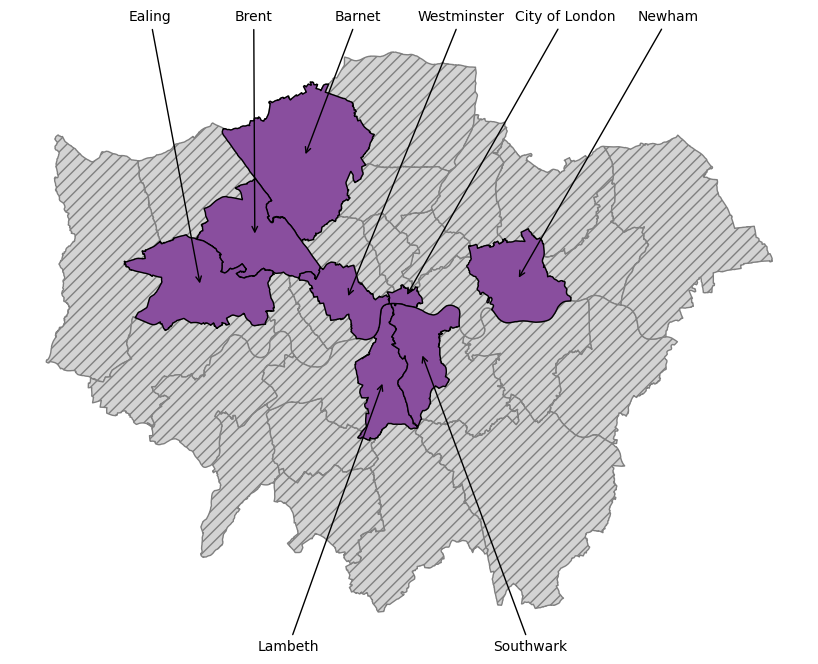

In [13]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in councils)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='grey', hatch="///")  # Default color for all areas
london_lad[london_lad['highlight']].plot(ax=ax, color="#894e9e", edgecolor='black')  # Highlighted councils

# # add scatter of comments - comment out to get map without scatter 
# ax.scatter(
#     comment_gdf['lon'],
#     comment_gdf['lat'],
#     s=10,
#     color="#a0e8ef",
#     alpha=0.2,
#     label='Comments'
# )  

def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
        df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()

plt.savefig("../figures/just_london_councils_highlighted.png", dpi=500)
plt.show()

### Local authority barchart 
Plot stacked vertical bar chart showing the number of applications and the proportion receiving comments. 

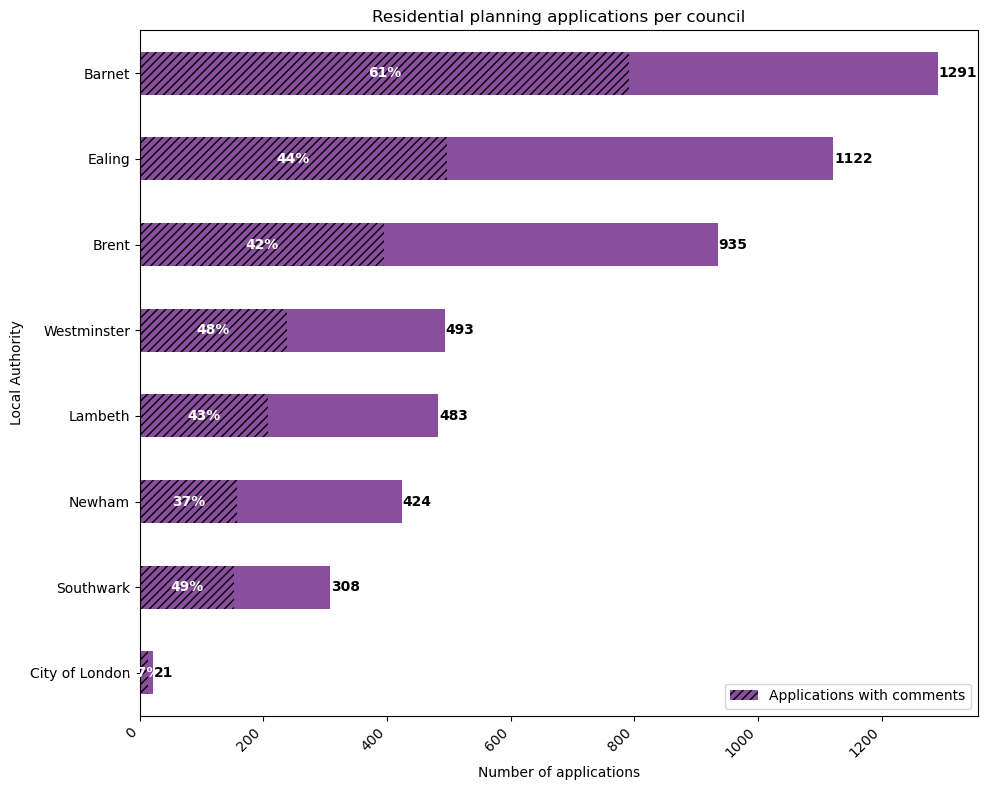

In [14]:
# make a copy to avoid modifying original
df = unique_app_counts.copy()

# compute the remainder (total minus subset). Clip to 0 to avoid negatives if data odd.
df['no_applications_remaining'] = (df['no_applications'] - df['no_applications_with_comments']).clip(lower=0)

# plot stacked bars: first the subset, then the remainder so subset is at the left of the bar
ax = df.plot.barh(
    x='council',
    y=['no_applications_with_comments', 'no_applications_remaining'],
    stacked=True,
    figsize=(10, 8),
    title='Residential planning applications per council',
    ylabel='Local Authority',
    xlabel='Number of applications',
    color=["#894e9e", "#894e9e"]  # same base color; we'll hatch the first
)

# patch list and counts
bars = ax.patches
n = len(df)

# apply hatching to the "with comments" bars (first n patches)
for i in range(n):
    bars[i].set_hatch('////')

# annotate:
# - bars[0..n-1] are the hashed (with_comments) segments
# - bars[n..2n-1] are the remainder segments
for i in range(n):
    bar_comments = bars[i]
    bar_remainder = bars[i + n]

    comments_w = bar_comments.get_width()
    remainder_w = bar_remainder.get_width()
    total_w = comments_w + remainder_w

    y = bar_comments.get_y() + bar_comments.get_height() / 2

    # --- 1) Hashed section percentage label (white) ---
    if total_w > 0:
        pct = comments_w / total_w * 100
        label = f'{pct:.0f}%'  # round to nearest whole %
    else:
        label = ''

    ax.text(
        bar_comments.get_x() + comments_w / 2,
        y,
        label,
        va='center',
        ha='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

    # --- 2) Total label to the right ---
    ax.text(
        bar_remainder.get_x() + remainder_w + 1,
        y,
        f'{int(total_w)}',
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# Only show legend for the hatched (with comments) section
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend([handles[0]], ['Applications with comments'], loc='lower right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../figures/bar_applications_per_council.png", dpi=500)
plt.show()


### Histogram of number of comments per planning application 

In [15]:
# format the application_df by adding comment counts
app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

application_df = ppf.format_df(application_df)

In [16]:
application_df = ppf.create_decision_outcomes_new(application_df, completion_date_col_name='decision_date')

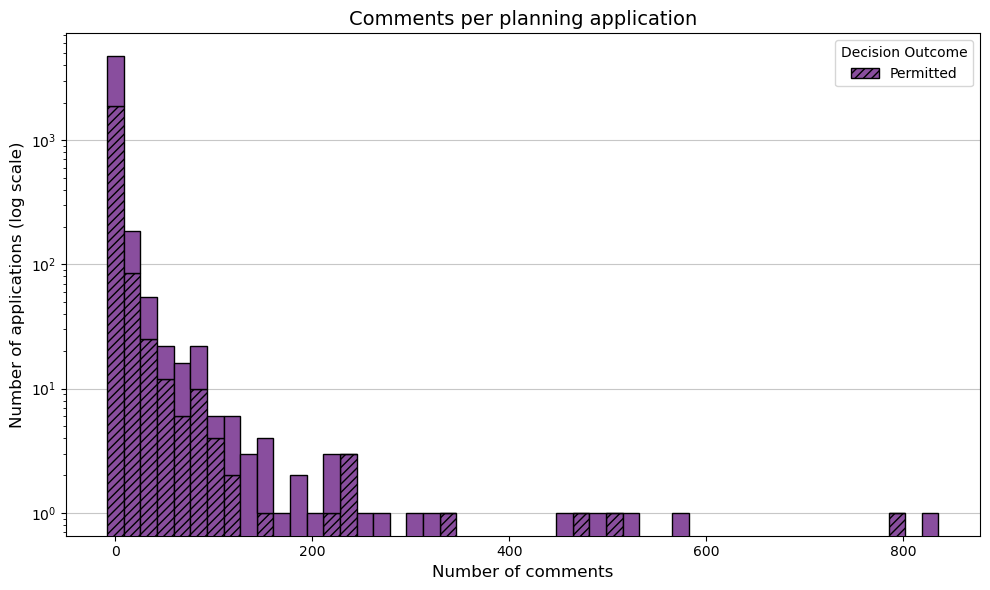

In [17]:
plt.figure(figsize=(10,6))

# Split data into two categories
permitted = application_df.loc[application_df['outcome'] == 'Permitted', 'comment_count']
not_permitted = application_df.loc[application_df['outcome'] != 'Permitted', 'comment_count']

# Common parameters
color = "#894e9e"
bins = 50

# Plot both datasets *in one call* for stacking
counts, bins, patches = plt.hist(
    [not_permitted, permitted],
    bins=bins,
    stacked=True,
    color=[color, color],
    edgecolor='black',
    alpha=1,
    align='left',
    label=['Permitted'],
    zorder=3
)

# Apply hatching only to the 'Permitted' bars (second group)
for patch in patches[0]:  # second dataset (index 1)
    patch.set_hatch('////')

# Log scale and labels
plt.yscale('log')
plt.title('Comments per planning application', fontsize=14)
plt.xlabel('Number of comments', fontsize=12)
plt.ylabel('Number of applications (log scale)', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.legend(title='Decision Outcome')
plt.tight_layout()
plt.savefig("../figures/hist_comments_per_application_permitted.png", dpi=500)
plt.show()

In [18]:
# Details of the dataset
db_host = 'https://athena.london.gov.uk'
db_user = 'odbc_readonly'
db_pass = 'odbc_readonly'
db_port = '10099'
db_name = 'gla-ldd-external'

# Creates connection to the dataset
es = Elasticsearch(
    [f"{db_host}:{db_port}"],
    basic_auth=(db_user, db_pass), 
    verify_certs=True,
    ca_certs='../athena_es_full_chain.crt'
)

# Check connection
if es.ping():
    print("Connected to Elasticsearch!")
else:
    print("Could not connect to Elasticsearch.")

Connected to Elasticsearch!


In [20]:
# The request return all planning applications over a five year period, starting 1/1/2015, with at least 1 social housing unit gain. 
application_df_new = esf.res_units_x_query(es, x_res_units=1, since_year="01/01/2021", to_year="01/07/2025")

# Format the data 
application_df_new = ppf.format_df(application_df_new)

print(f'Number of residential planning applications: {len(application_df_new)}')

ConnectionTimeout: Connection timed out

In [ ]:
application_df

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,comment_count,outcome
0,24/02204/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...,1,Permitted
1,25/0089,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...,0,Permitted
2,24/1783,NaT,NaT,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...,5,Not Permitted
3,25/00205/PRECOU,NaT,NaT,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...,0,Not Permitted
4,25/00181/PRECOU,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...,1,Not Permitted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5072,23/3665,NaT,NaT,Brent,1,NaN,NaN,NaN,PP-12623129,2.020331e+08,Approved,Approved,NaN,"68 Watford Road, Wembley, HA0 3ES",NaN,"polygon=linearring(x=[516710.0, 516717.1, 5167...",NaN,Change of use from dwellinghouse to large 9 pe...,4,Permitted
5073,22/03810/FUL,NaT,NaT,Lambeth,1,NaN,NaN,NaN,PP-11628675,1.009496e+10,Approved,Approved,Development Control Pseudo Street,Garages To The Rear Of 40 And 42 Gracefield Ga...,NaN,GEOMETRYCOLLECTION (POLYGON ((530362.15 172026...,"polygon=linearring(x=[-0.12605149999999998, -0...",Erection of 1 single storey dwellinghouse (Use...,8,Permitted
5074,23/02837/FUL,NaT,NaT,Lambeth,2,NaN,NaN,NaN,PP-12426853,1.000219e+11,Approved,Approved,NaN,17 Tarrington Close,NaN,NaN,NaN,NaN,3,Permitted
5075,23/1057,NaT,NaT,Brent,4,NaN,NaN,NaN,PP-12056911,2.020633e+08,Refused,Refused,NaN,"57 Northwick Avenue, Harrow, HA3 0AU",NaN,"polygon=linearring(x=[516747.65, 516732.3, 516...",NaN,Proposed conversion of dwellinghouse to 4x sel...,2,Not Permitted


In [ ]:
application_df_new = application_df_new[['affordable_housing_fast_track',
       'total_no_proposed_residential_units_shared_equity',
       'total_no_proposed_residential_units_london_living_rent',
       'total_no_proposed_residential_units',
       'total_no_proposed_residential_units_social_rent',
       'total_no_proposed_residential_units_discount_market_sale',
       'total_no_proposed_residential_units_discount_market_rent_charged_at_london_rents',
       'total_no_proposed_residential_units_starter_homes',
       'total_no_proposed_residential_units_london_affordable_rent',
       'total_no_proposed_residential_units_market_for_rent',
       'total_no_proposed_residential_units_discount_market_rent',
       'total_no_proposed_residential_units_intermediate',
       'total_no_proposed_residential_units_london_shared_ownership',
       'total_no_proposed_residential_units_self_build_and_custom_build',
       'total_no_proposed_residential_units_market_for_sale', 'borough',
       'street_name', 'site_name', 'decision_date', 'valid_date', 'lpa_app_no']]

In [ ]:
application_df_new.head()

,affordable_housing_fast_track,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units_london_living_rent,total_no_proposed_residential_units,total_no_proposed_residential_units_social_rent,total_no_proposed_residential_units_discount_market_sale,total_no_proposed_residential_units_discount_market_rent_charged_at_london_rents,total_no_proposed_residential_units_starter_homes,total_no_proposed_residential_units_london_affordable_rent,total_no_proposed_residential_units_market_for_rent,...,total_no_proposed_residential_units_intermediate,total_no_proposed_residential_units_london_shared_ownership,total_no_proposed_residential_units_self_build_and_custom_build,total_no_proposed_residential_units_market_for_sale,borough,street_name,site_name,decision_date,valid_date,lpa_app_no
0,False,0,0,1,0,0,0,0,0,0,...,0,0,0,1,Haringey,Sheldon Avenue,"11 Sheldon Avenue, Hornsey, London, N6 4JS",NaT,2024-08-02,HGY/2024/2154
1,False,0,0,1,0,0,0,0,0,1,...,0,0,0,0,Greenwich,None,"13 WAVERLEY CRESCENT, PLUMSTEAD, LONDON, SE18 7QT",NaT,2025-02-05,25/0361/F
2,NaN,0,0,15,0,0,0,0,0,0,...,0,0,0,15,Hounslow,None,None,NaT,2025-02-05,PAC/2025/0379
3,False,0,0,1,0,0,0,0,0,1,...,0,0,0,0,Greenwich,None,"16 MONTBELLE ROAD, ELTHAM, LONDON, SE9 3PB",NaT,2025-03-06,25/0732/F
4,NaN,0,0,1,0,0,0,0,0,1,...,0,0,0,0,Islington,Newington Green,None,NaT,2025-02-05,P2025/0356/PRA


In [ ]:
application_df = pd.merge(application_df, application_df_new, left_on='lpa_app_no', right_on='lpa_app_no', how='left')

In [ ]:
ppf.housing_type(application_df)

In [32]:
# scatter plot of comment count vs application_details.residential_details.total_no_proposed_residential_units in applictaion_df

with_comments = application_df[application_df['comment_count'] > 0]

# Filtered data
x = with_comments['application_details.residential_details.total_no_proposed_residential_units']
y = with_comments['comment_count']

# Add small additive jitter
x_jittered = x + np.random.uniform(-10, 10, size=len(x))  # adjust ±2 units as needed
y_jittered = y + np.random.uniform(-10, 10, size=len(y))  # adjust ±2 units as needed

plt.figure(figsize=(10,6))
plt.scatter(x_jittered, y_jittered, alpha=0.3)
plt.title('Comments vs Proposed Residential Units (with jitter)')
plt.xlabel('Total Number of Proposed Residential Units')
plt.ylabel('Number of Comments')
plt.grid(True)
plt.show()


KeyError: 'application_details.residential_details.total_no_proposed_residential_units'

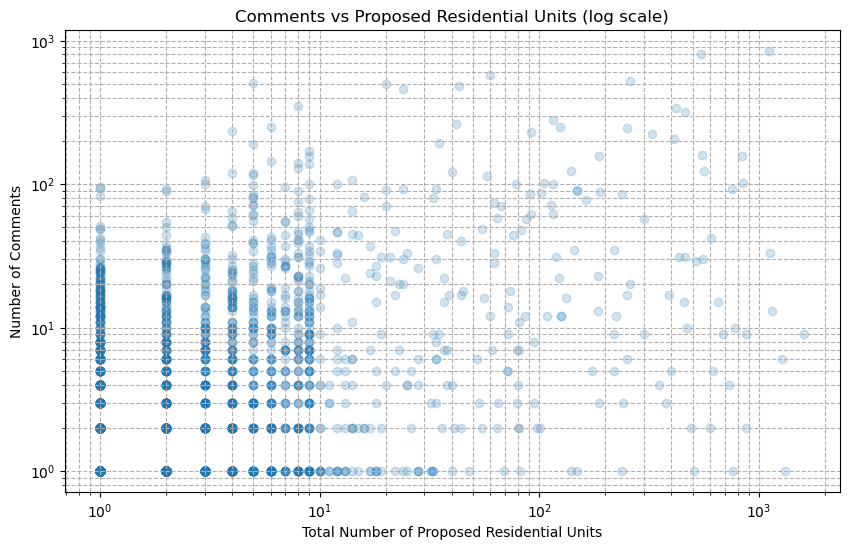

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    with_comments['application_details.residential_details.total_no_proposed_residential_units'],
    with_comments['comment_count'],
    alpha=0.2
)
plt.xscale('log')
plt.yscale('log')
plt.title('Comments vs Proposed Residential Units (log scale)')
plt.xlabel('Total Number of Proposed Residential Units')
plt.ylabel('Number of Comments')
plt.grid(True, which="both", ls="--")
plt.show()
